# This is a notebook for messing with parameter distributions to get "tight" and "wide" simulations

### Load dependencies

In [1]:
import os
import json
import sympy
import requests

import pyciemss
import pyciemss.visuals.plots as plots
import pyciemss.visuals.vega as vega
import pyciemss.visuals.trajectories as trajectories

from mira.metamodel import *
from mira.modeling.amr.petrinet import AMRPetriNetModel, template_model_to_petrinet_json
from mira.sources.amr.petrinet import template_model_from_amr_json

### Grab a few models

In [2]:
MODEL_PATH = "https://raw.githubusercontent.com/DARPA-ASKEM/simulation-integration/main/data/models/"

model1 = os.path.join(MODEL_PATH, "SEIRD_base_model01_petrinet.json")
model2 = os.path.join(MODEL_PATH, "SEIRHD_base_model01_petrinet.json")
model3 = os.path.join(MODEL_PATH, "LV_sheep_foxes.json")

### Set parameters for sampling

In [3]:
start_time = 0.0
end_time = 100.0
logging_step_size = 10.0
num_samples = 100

## Sample the model

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,persistent_death_param,persistent_gamma_param,persistent_I0_param,D_state,E_state,I_state,R_state,S_state,infected_observable_state,dead_observable_state
0,0,0,10.0,0.314078,0.007034,0.240406,6.01508,0.375621,32.783817,29.595821,53.025963,19339974.0,29.595821,0.375621
1,1,0,20.0,0.314078,0.007034,0.240406,6.01508,0.976326,46.420498,42.129662,137.827850,19339814.0,42.129662,0.976326
2,2,0,30.0,0.314078,0.007034,0.240406,6.01508,1.829547,65.905502,59.815071,258.276154,19339654.0,59.815071,1.829547
3,3,0,40.0,0.314078,0.007034,0.240406,6.01508,3.040918,93.568962,84.922607,429.284790,19339432.0,84.922607,3.040918
4,4,0,50.0,0.314078,0.007034,0.240406,6.01508,4.760754,132.841354,120.566849,672.072571,19339114.0,120.566849,4.760754


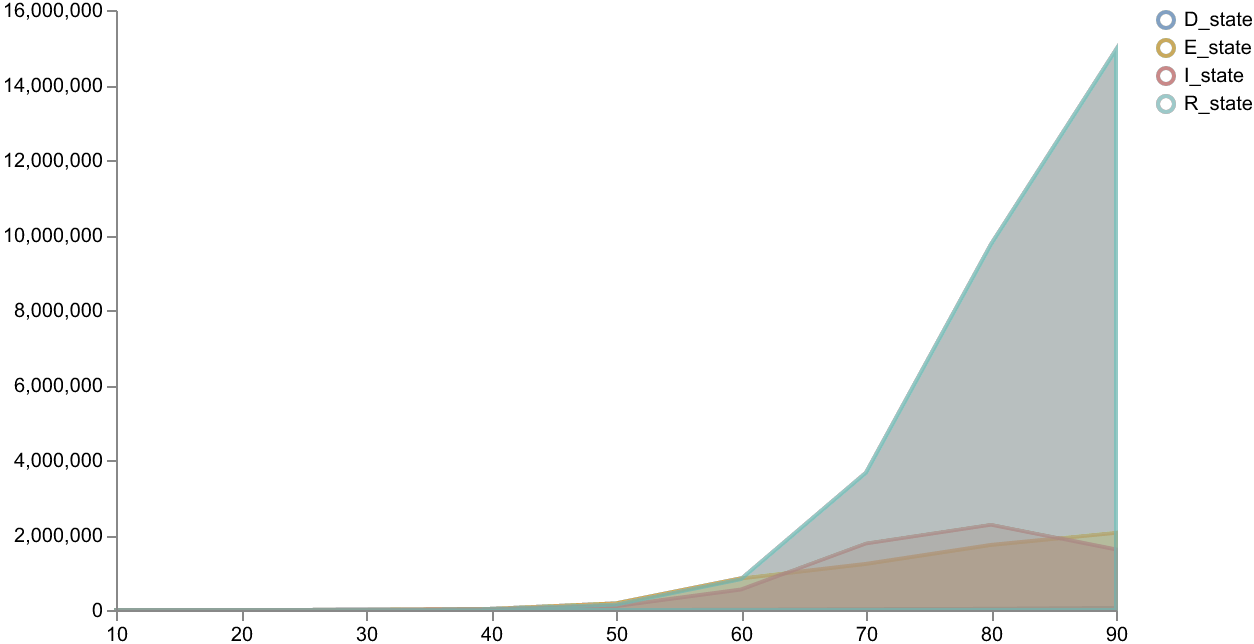

In [4]:
result1 = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
# schema = plots.trajectories(result1["data"], keep=".*_state")
schema = plots.trajectories(result1["data"], keep=["E_state", "I_state", "R_state", "D_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

## Change parameter values and uncertainty from the AMR

### Load the model as a template model (from the url)

In [5]:
response = requests.get(model1)
tm = template_model_from_amr_json(json.loads(response.text))

# Print parameters
tm.parameters

{'beta': Parameter(name='beta', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=1/day), value=0.4, distribution=Distribution(type='Uniform1', parameters={'minimum': 0.05, 'maximum': 0.8})),
 'total_population': Parameter(name='total_population', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=person), value=19340000.0, distribution=None),
 'I0': Parameter(name='I0', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=person), value=10.0, distribution=Distribution(type='Uniform1', parameters={'minimum': 1.0, 'maximum': 15.0})),
 'delta': Parameter(name='delta', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=1/day), value=0.25, distribution=None),
 'death': Parameter(name='death', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=1/day), value=0.007, distribution=Distribution(type='Uniform1', paramete

### Change parameter values and distributions

In [6]:
# Change `beta` parameter value
tm.parameters["beta"].value = 0.2
# Tighten `beta` distribution
tm.parameters["beta"].distribution = Distribution(type='StandardUniform1',
                                                 parameters={'minimum': 0.199, 'maximum': 0.201})

# Change `gamma` parameter value
tm.parameters["gamma"].value = 0.25
# Remove `gamma` distribution
tm.parameters["gamma"].distribution = None

# Remove `I0` distribution
tm.parameters["I0"].distribution = None
# Remove `death` distribution
tm.parameters["death"].distribution = None

# Save as updated AMR
with open('update_parameters_example.json', 'w') as fh:
    json.dump(template_model_to_petrinet_json(tm), fh, indent=1)

### Sample the updated model

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,D_state,E_state,I_state,R_state,S_state,infected_observable_state,dead_observable_state
0,0,0,10.0,0.200584,0.357566,18.997374,20.905733,50.723328,19339952.0,20.905733,0.357566
1,1,0,20.0,0.200584,0.681399,14.534698,16.223989,96.661385,19339916.0,16.223989,0.681399
2,2,0,30.0,0.200584,0.931346,11.198531,12.502106,132.118088,19339888.0,12.502106,0.931346
3,3,0,40.0,0.200584,1.123942,8.628799,9.633259,159.439041,19339864.0,9.633259,1.123942
4,4,0,50.0,0.200584,1.272342,6.648737,7.422713,180.490753,19339848.0,7.422713,1.272342


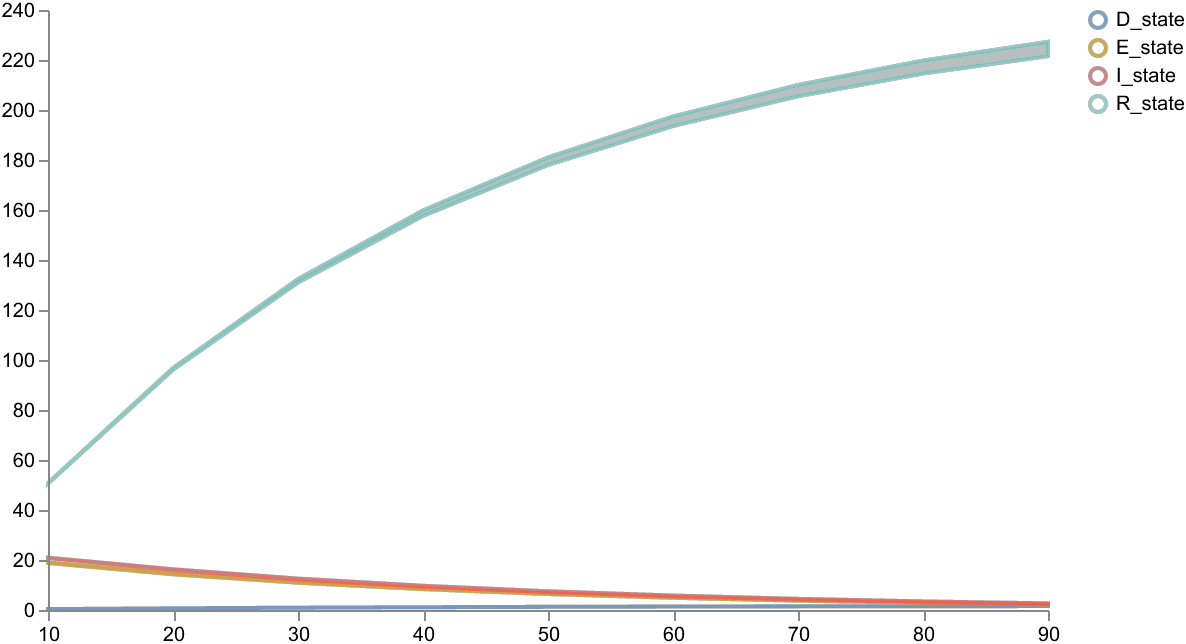

In [7]:
updated_model = "update_parameters_example.json"
result1 = pyciemss.sample(updated_model, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
# schema = plots.trajectories(result1["data"], keep=".*_state")
schema = plots.trajectories(result1["data"], keep=["E_state", "I_state", "R_state", "D_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

### Change parameters again (from the local model)

In [ ]:
filename = updated_model
with open(filename, 'r') as fh:
    tm = template_model_from_amr_json(json.load(fh))

# Change `beta` parameter value
tm.parameters["beta"].value = 50.0

# Change `Myy` distribution
tm.parameters["Myy"].distribution = Distribution(type='StandardUniform1',
                                                 parameters={'minimum': 40.0, 'maximum': 80.0})

# Save as updated AMR
with open('update_parameters_example.json', 'w') as fh:
    json.dump(template_model_to_petrinet_json(tm), fh, indent=1)